# Module 8: Connectivity

Number of edges: 16


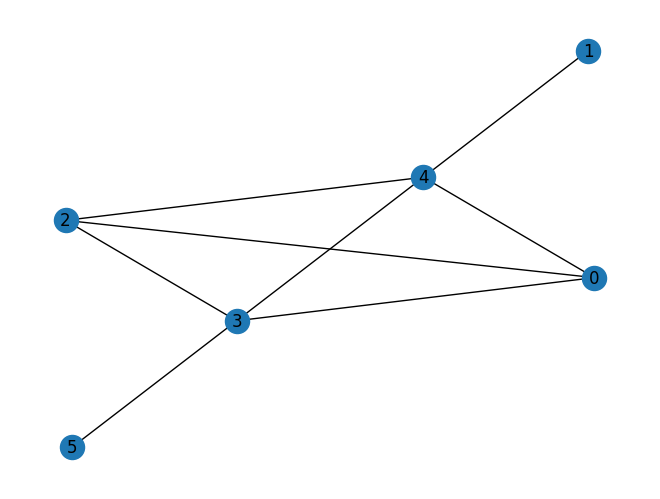

In [31]:
from graph_algorithms_the_fun_way import graph as gr
from graph_algorithms_the_fun_way import shortest_path as sp
from graph_algorithms_the_fun_way import search as src
from graph_algorithms_the_fun_way import connected as con
import networkx as nx


# Make a random BA graph
G = nx.erdos_renyi_graph(6, 0.3, directed=False, seed=42)
pos = nx.kamada_kawai_layout(G)
nx.draw(G, with_labels=True, pos=pos)

# Make edgelist for converting to GATFW graph
edgelist = list(nx.edges(G))
# print(edgelist[:10])  # Print the first 10 edges to verify

# Convert nx graph to GATFW graph g
g = gr.Graph(len(G), undirected=True)  # Create a new graph with 100 vertices
for (u, v) in edgelist:
    g.insert_edge(u, v, 1.0)  # Assuming a weight of 1.0 for each edge

# for i in (g.make_edge_list()):  # Print the first 10 edges to verify
#     print(i.from_node, i.to_node, i.weight)

print(f"Number of edges: {len(g.make_edge_list())}")

In [32]:
# Dijskstra's shortest path
d = sp.Dijkstras(g, 0)
print(d)


[-1, 4, 0, 0, 0, 3]


In [33]:
def Dijkstra_to_nodelist(dijkstras_prev_node_list, index):
    index = index
    nodelist = []
    prev = dijkstras_prev_node_list
    
    nodelist.append(index)
    while prev[index] != -1:
        nodelist.append(d[index])
        index = prev[index]
    return nodelist

import random
num_nodes = g.num_nodes

nl = Dijkstra_to_nodelist(d,5)
print(nl)


[5, 3, 0]


In [34]:
print(src.dfs_connected_components(g))
print(f"Components: {max(src.dfs_connected_components(g))+1}")

[0, 0, 0, 0, 0, 0]
Components: 1


In [39]:
art = con.find_articulation_points(g)
print(f"Artic points: {[i for i in art]}")

Artic points: [3, 4]


In [38]:
brd = con.find_bridges(g)

print("Bridges: ")
for i in brd:
    print(list((i.from_node, i.to_node)))

Bridges: 
[4, 1]
[3, 5]
